# Timeline of novel epidemic-inducing symptoms

- **Summary**: This document graphs the arrival of epidemics caused by novel symptoms. 
- **Data Required:** `epidemics_marani_240816.xlsx`

- **Note:** Malaria and mpox (monkeypox) are not in the dataset because they have only caused outbreaks. 

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare epidemic data

In [2]:
## Read epidemic data
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")

## Sort epidemics by start year
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)


In [3]:
## Display dataset head
# df.head()


## 1. Prepare dataframe for novel symptoms

In [4]:
## Keep only the first occurrence of 'disease' column
df_arrival = df.drop_duplicates(subset='disease', keep='first').reset_index(drop=True)

## Create new disease column
df_arrival['new_disease'] = df_arrival['disease']


In [5]:
## Display dataset
# df_arrival


In [6]:
## Clean epidemics caused by multiple symptoms
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, dysentery", "dysentery")
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, relapsing fever, dysentery", "relapsing fever")
df_arrival['new_disease'] = df_arrival['new_disease'].replace("typhus, typhoid, dysentery", "typhoid")

## Drop later duplicates of "dysentery," "relapsing fever," "typhoid"
df_arrival_new = df_arrival.drop_duplicates(subset='new_disease', keep='first').reset_index(drop=True)


In [7]:
## Display dataset
# df_arrival_new


## 2. Graph timeline for novel epidemic-inducing symptoms

In [8]:
## Prepare symptom arrival data for graph
viral_df = df_arrival_new[df_arrival_new['is_vira_only'] == 1]
nonviral_df = df_arrival_new[df_arrival_new['is_vira_only'] == 0]

## Since some symptoms are caused by both viral and non-viral infections,
## we can also consider all symptoms with viral infections as "viral"
# viral_df = df_arrival_new[df_arrival_new['contains_vira'] == 1]
# nonviral_df = df_arrival_new[df_arrival_new['contains_vira'] == 0]


In [9]:
## Group unique viral/non-viral diseases by epidemic start year,
## in case more than 1 unique novel disease arrives in a year
viral_per_year = viral_df.groupby('year_start')['new_disease'].unique()
nonviral_per_year = nonviral_df.groupby('year_start')['new_disease'].unique()


In [10]:
## Set paramters of graph titles and markers
title_size = 12
markersize = 15

## Set parameters of symptom labels
fontsize = 9
initial_offset = 0.14
offset = 0.18


<Figure size 1500x600 with 0 Axes>

Text(1507, 0.14, 'smallpox')

Text(1510, 0.32, 'influenza')

Text(1592, 0.5, 'measles')

Text(1647, 0.68, 'yellow fever')

...

Text(0.5, 0, 'Epidemic start year')

Text(0, 0.5, 'Epidemic-inducing symptom')

([<matplotlib.axis.XTick at 0x132082150>,
 [Text(1500, 0, '1500'),
  Text(1550, 0, '1550'),
  Text(1600, 0, '1600'),
  Text(1650, 0, '1650'),
  Text(1700, 0, '1700'),
  Text(1750, 0, '1750'),
  Text(1800, 0, '1800'),
  Text(1850, 0, '1850'),
  Text(1900, 0, '1900'),
  Text(1950, 0, '1950'),
  Text(2000, 0, '2000')])

([], [])

(-4.2, 3.55)

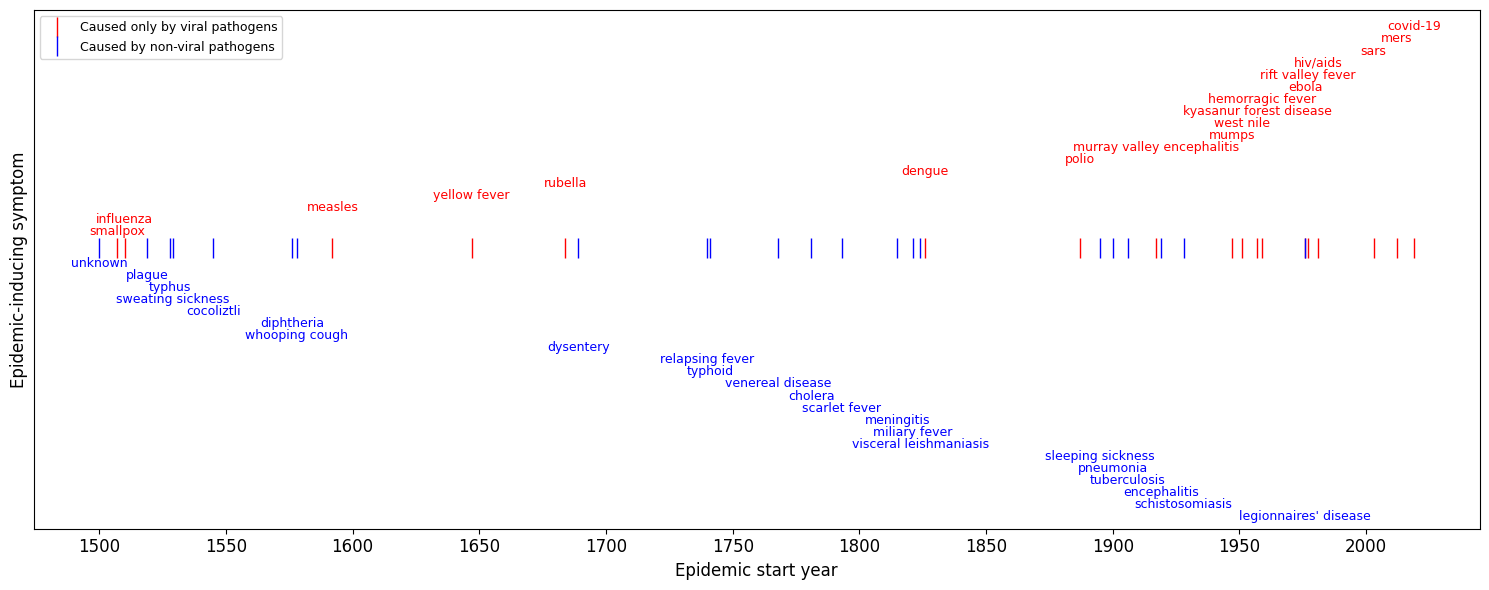

In [12]:
## Plot symptom arrival
plt.figure(figsize=(15, 6))

## Limit the number of novel symptoms plotted per year
max_diseases_per_year = 5


## Plot viral symptoms above the y-axis
j = 0  ## Initialize offset variable j
for year, diseases in viral_per_year.items():
    for i, disease in enumerate(diseases[:max_diseases_per_year]):
        y_offset = j * offset  ## Calculate y offset based on offset j
        y = initial_offset + y_offset  ## Increment y-coordinate for each disease
        plt.text(year, y, disease, ha='center', va='bottom', color='red', fontsize=fontsize)
    j += 1  ## Increment j for next group of diseases

## Plot non-viral symptoms below the y-axis
j = 0  ## Reinitialize offset variable j
for year, diseases in nonviral_per_year.items():
    for i, disease in enumerate(diseases[:max_diseases_per_year]):
        y_offset = j * offset  ## Calculate y offset based on offset j
        y = - initial_offset - y_offset  ## Decrement y-coordinate for each disease
        plt.text(year, y, disease, ha='center', va='top', color='blue', fontsize=fontsize)
    j += 1  ## Increment j for next group of diseases

    
## Plot viral '|' markers in red and non-viral '|' markers in blue
plt.plot(viral_df['year_start'], [0] * len(viral_df), '|', color='red', 
         markersize=markersize, label='Caused only by viral pathogens')
plt.plot(nonviral_df['year_start'], [0] * len(nonviral_df), '|', color='blue', 
         markersize=markersize, label='Caused by non-viral pathogens')

## Add legend
plt.legend(loc='upper left', fontsize=fontsize)


## Set graph titles and ticks
# plt.title('Arrival of Novel Epidemic-Inducing Symptoms (1500-2023)', fontsize=title_size + 3)
plt.xlabel('Epidemic start year', fontsize=title_size)
plt.ylabel('Epidemic-inducing symptom', fontsize=title_size)

plt.xticks(range(1500, 2023, 50), fontsize=title_size)  ## Adjust x-axis ticks
plt.yticks([])  ## Hide y-axis ticks

plt.ylim(-4.2, 3.55)  ## Adjust y-axis limits
plt.tight_layout()

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '01_novel_symptom_arrival.jpg', dpi=400, bbox_inches = 'tight')

plt.show()
